In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

# Add path to import modules from src
sys.path.append('..')

from src.kitti_utils import load_kitti_calib
from src.optical_flow import compute_sparse_flow
from src.geometry import filter_static_points

BASE_PATH = "D:/reyci/Politecnico di Milano/2025-2/Image Analysis and CV/Project/Code/IACV-Depth-Estimation-from-Temporal-Stereo-in-Monocular-Driving-Sequences-/data/raw/2011_09_26_drive_0001_extract"
IMG_PATH = os.path.join(BASE_PATH, "image_02/data")
CALIB_CAM_PATH = os.path.join(BASE_PATH, "calib/calib_cam_to_cam.txt")
CALIB_VELO_PATH = os.path.join(BASE_PATH, "calib/calib_velo_to_cam.txt")

# Frame selection (frames where any parked car appears)
idx_t = 62
idx_t1 = 63

img_t = cv2.imread(os.path.join(IMG_PATH, f"{idx_t:010d}.png"))
img_t1 = cv2.imread(os.path.join(IMG_PATH, f"{idx_t1:010d}.png"))

# Load theoretical FOE from calibration
P_rect, _ = load_kitti_calib(CALIB_CAM_PATH, CALIB_VELO_PATH)
foe = np.array([P_rect[0, 2], P_rect[1, 2]])

print(f"Epipolar analysis ready for frame {idx_t} with FOE at {foe}")

Epipolar analysis ready for frame 62 with FOE at [609.5593 172.854 ]


In [3]:
# 1. Compute optical flow
p0, p1 = compute_sparse_flow(img_t, img_t1)

# 2. Apply the Epipolar Constraint (Fundamental Matrix F)
# The filter_static_points function returns a boolean mask
# True = Static (satisfies x'Fx = 0), False = Dynamic (does not satisfy it)
is_static = filter_static_points(p0, p1, foe, threshold=0.4)

p0_static = p0[is_static]
p1_static = p1[is_static]

p0_dynamic = p0[~is_static]
p1_dynamic = p1[~is_static]

print(f"Total points: {len(p0)}")
print(f"Static points (Scene): {len(p0_static)}")
print(f"Detected dynamic points: {len(p0_dynamic)}")

Total points: 98
Static points (Scene): 88
Detected dynamic points: 10


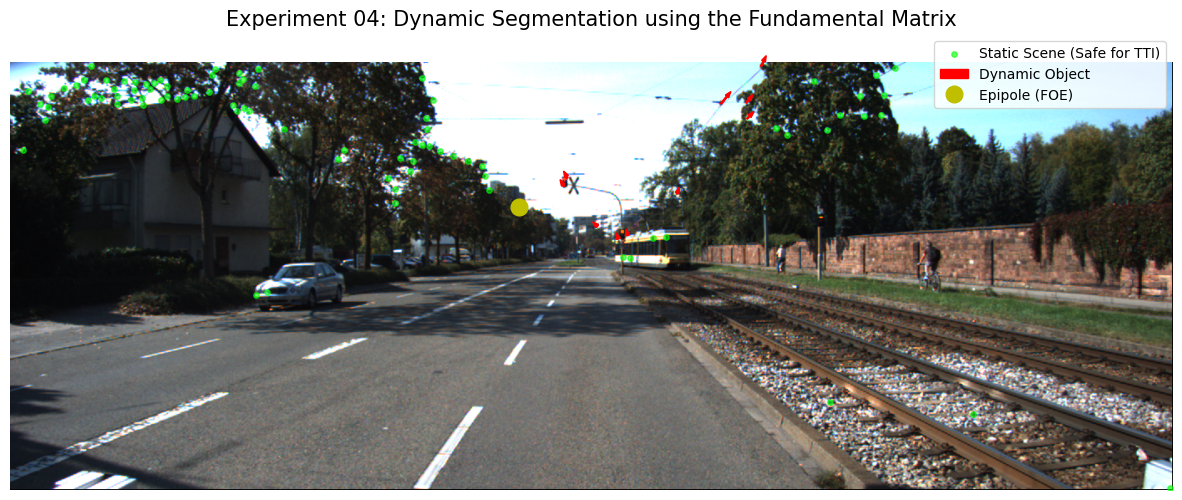

10.20% of the scene is in relative motion.


In [4]:
plt.figure(figsize=(15, 8))
plt.imshow(cv2.cvtColor(img_t, cv2.COLOR_BGR2RGB))

# Plot static points (Green) - Road, buildings, traffic signs
plt.scatter(
    p0_static[:, 0],
    p0_static[:, 1],
    color='lime',
    s=15,
    alpha=0.6,
    label='Static Scene (Safe for TTI)'
)

# Plot dynamic points (Red) - Other cars, pedestrians
for i in range(len(p0_dynamic)):
    a, b = p0_dynamic[i]
    c, d = p1_dynamic[i]

    plt.arrow(
        a, b,
        c - a,
        d - b,
        color='red',
        head_width=5,
        width=1.5,
        label='Dynamic Object' if i == 0 else ""
    )

# Draw the FOE
plt.plot(foe[0], foe[1], 'yo', markersize=12, label='Epipole (FOE)')

plt.title(
    "Experiment 04: Dynamic Segmentation using the Fundamental Matrix",
    fontsize=15
)

plt.legend()
plt.axis('off')
plt.show()

# Conclusion
perc_dynamic = (len(p0_dynamic) / len(p0)) * 100
print(f"{perc_dynamic:.2f}% of the scene is in relative motion.")